<a href="https://colab.research.google.com/github/astinurin/Machine-Learning_2024/blob/Jobsheet-11/Jobsheet_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦁 Praktikum 1

Klasifikasi 🐱 dan 🐶

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/My Drive/Machine Learning/dataset'


In [ ]:
# Langkah 1 - Import Library
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Langkah 2 - Pra Pengolahan Data**

Pada tahap ini kita akan sedikit melakukan manipulasi pada citra yang digunakan. Manipulasi yang dilakukan diantaranya adalah normalisasi nilai piksel, koreksi kemiringan, pembesaran (zoom), dan flip.

In [ ]:
# Langkah 2.1. Pra Pengolahan Data Training
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
training_set = train_datagen.flow_from_directory('/content/drive/My Drive/Machine Learning/dataset/training_set',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

Found 8000 images belonging to 2 classes.


In [ ]:
# Langkah 2.2. Pra Pengolahan Data Testing
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('/content/drive/My Drive/Machine Learning/dataset/test_set',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 2000 images belonging to 2 classes.


**Langkah 3 - Pembuatan Model CNN**

In [ ]:
# Langkah 3.1.  - Inisiasi Model CNN
cnn = tf.keras.models.Sequential()

In [ ]:
# Langkah 3.2. - Pembuatan Layer Konvolusi 1
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Langkah 3.3 - Pembuatan Layer Pooling 1
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
# Langkah 3.4 - Pembuatan Layer Konvolusi 2 dan Pooling 2
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
# Langkah 3.5 - Flattening
cnn.add(tf.keras.layers.Flatten())

In [ ]:
# Langkah 3.6 - Fully Connected Layer 1 (Input)
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [ ]:
# Langkah 3.7 - Fully Connected Layer 2 (Output)
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [ ]:
# Langkah 3.8 - Compile Model CNN
cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

**Langkah 4 - Fit CNN**

In [ ]:
cnn.fit(x = training_set, validation_data = test_set, epochs = 25)

Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 1359s 5s/step - accuracy: 0.5507 - loss: 0.6945 - val_accuracy: 0.6430 - val_loss: 0.6320
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 397ms/step - accuracy: 0.6796 - loss: 0.5959 - val_accuracy: 0.6855 - val_loss: 0.6190
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 150s 431ms/step - accuracy: 0.7073 - loss: 0.5586 - val_accuracy: 0.7125 - val_loss: 0.5815
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 400ms/step - accuracy: 0.7328 - loss: 0.5311 - val_accuracy: 0.7640 - val_loss: 0.5038
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 100s 393ms/step - accuracy: 0.7461 - loss: 0.5097 - val_accuracy: 0.7540 - val_loss: 0.5072
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 100s 391ms/step - accuracy: 0.7734 - loss: 0.4640 - val_accuracy: 0.7715 - val_loss: 0.4913
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 398ms/step - accuracy: 0.7716 - loss: 0.4675 - val_accuracy: 0.7665 - val_loss: 0.4875
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 428ms/step - accuracy: 0.7913 - loss: 0.4477

**Langkah 5 - Prediksi dengan 1 Citra**

In [ ]:
import numpy as np
from keras.preprocessing import image
test_image = image.load_img('/content/drive/My Drive/Machine Learning/dataset/single_prediction/cat_or_dog_1.jpg', target_size = (64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
training_set.class_indices
if result[0][0] == 1:
  prediction = 'dog'
else:
  prediction = 'cat'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


# 🚓 Praktikum 2
Klasifikasi Multi-label dengan Data CIFAT

**Langkah 1 - Load Library**

In [ ]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

**Langkah 2 - Unduh Dataset CIFAR**

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


**Langkah 3 - Verifikasi Data**

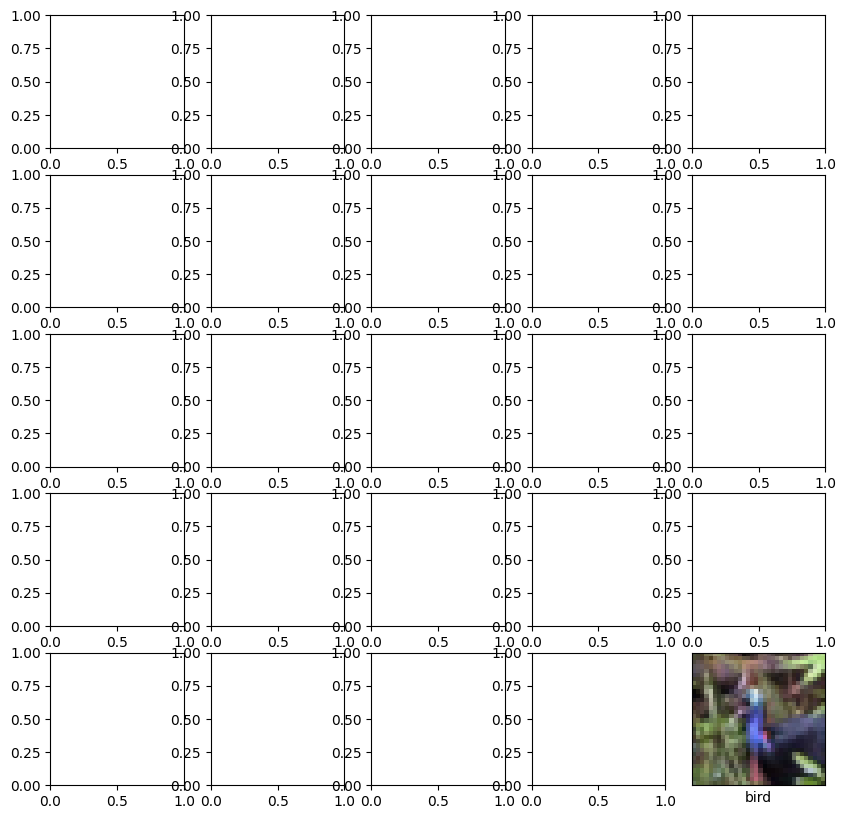

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25): plt.subplot(5,5,i+1)
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.imshow(train_images[i])
# The CIFAR labels happen to be arrays,
# which is why you need the extra index
plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Langkah 4 - Buat Model CNN**

In [ ]:
# Langkah 4.1. - Buat Layer Konvolusi
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Langkah 4.2. - Cek Arsitektur Konvolusi
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Langkah 4.3. - Tambahkan Layer Fully Connected
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [ ]:
# Langkah 4.4. - Cek Arsitektur Model CNN
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Langkah 4.5. - Compile Model CNN
model.compile(optimizer='adam',
 loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
 metrics=['accuracy'])

In [ ]:
# Langkah 5 - Fit Model
history = model.fit(train_images, train_labels, epochs=10,
validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.3512 - loss: 1.7547 - val_accuracy: 0.5203 - val_loss: 1.2902
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.5712 - loss: 1.2013 - val_accuracy: 0.5965 - val_loss: 1.1451
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6429 - loss: 1.0160 - val_accuracy: 0.6614 - val_loss: 0.9648
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.6834 - loss: 0.9028 - val_accuracy: 0.6810 - val_loss: 0.9121
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.7067 - loss: 0.8346 - val_accuracy: 0.6952 - val_loss: 0.8788
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 51ms/step - accuracy: 0.7267 - loss: 0.7771 - val_accuracy: 0.7064 - val_loss: 0.8551
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7489 - loss: 0.7205 - val_accuracy: 0.6956 - val_loss: 0.8896
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.7589 -

313/313 - 4s - 14ms/step - accuracy: 0.7191 - loss: 0.8424


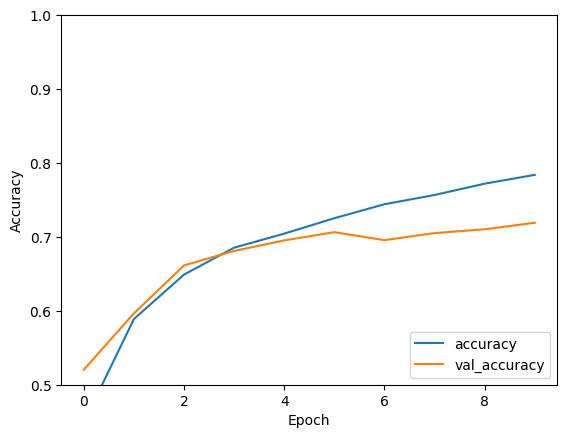

In [ ]:
# Langkah 6 - Evaluasi Model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

In [ ]:
# Langkah 7 - Cetak Hasil Akurasi
print(test_acc)

0.7190999984741211


Berapa akurasi yang Anda dapatkan?

**Jawab :**
Akurasi yg saya dapat adalah sekitar 71,91% atau jika dibulatkan menjadi 72%

# 🚨 Tugas






*   Modifikasi model CNN pada praktikum 2 sehingga didapatkan akurasi testing lebih dari 80%.



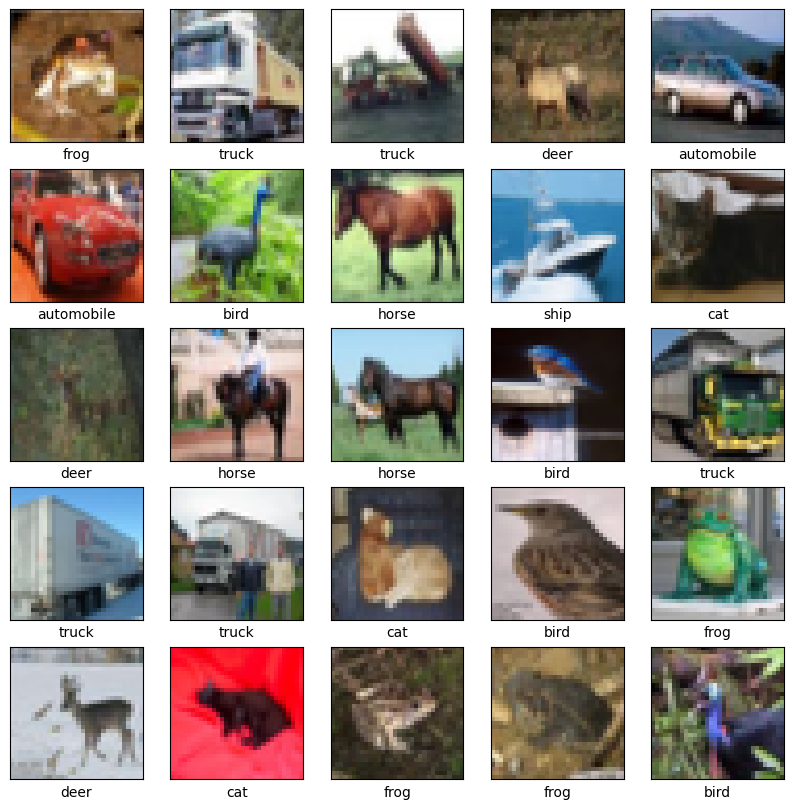

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


781/781 ━━━━━━━━━━━━━━━━━━━━ 818s 1s/step - accuracy: 0.1889 - loss: 12.4916 - val_accuracy: 0.3251 - val_loss: 2.6539
Epoch 2/20
  1/781 ━━━━━━━━━━━━━━━━━━━━ 10:57 843ms/step - accuracy: 0.2188 - loss: 2.7629

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


781/781 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.2188 - loss: 2.7629 - val_accuracy: 0.3451 - val_loss: 2.6089
Epoch 3/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 813s 1s/step - accuracy: 0.3571 - loss: 2.2226 - val_accuracy: 0.4521 - val_loss: 1.5660
Epoch 4/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.4531 - loss: 1.5979 - val_accuracy: 0.4409 - val_loss: 1.5849
Epoch 5/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 813s 1s/step - accuracy: 0.4310 - loss: 1.6536 - val_accuracy: 0.5038 - val_loss: 1.4596
Epoch 6/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.4062 - loss: 1.6192 - val_accuracy: 0.4922 - val_loss: 1.4945
Epoch 7/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 823s 1s/step - accuracy: 0.4790 - loss: 1.5377 - val_accuracy: 0.5788 - val_loss: 1.2694
Epoch 8/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.6406 - loss: 1.1125 - val_accuracy: 0.5769 - val_loss: 1.2768
Epoch 9/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 814s 1s/step - accuracy: 0.5276 - loss: 1.4388 - val_accuracy: 0

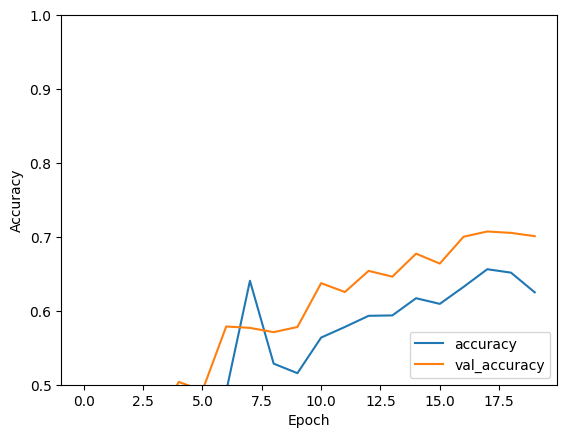

In [ ]:
# Langkah 1 - Load Library
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Langkah 2 - Unduh Dataset CIFAR
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalisasi data
train_images, test_images = train_images / 255.0, test_images / 255.0

# Langkah 3 - Verifikasi Data
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])  # Menghilangkan ticks pada sumbu x
    plt.yticks([])  # Menghilangkan ticks pada sumbu y
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])  # Menambahkan label class pada gambar
plt.show()

# Langkah 4 - Buat Model CNN yang Lebih Kompleks
model = models.Sequential()

# Layer Konvolusi dan MaxPooling dengan lebih banyak filter dan padding
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # Padding 'same' menjaga ukuran input
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))  # Padding 'same' menjaga ukuran input
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))  # Padding 'same' menjaga ukuran input
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))  # Padding 'same' menjaga ukuran input

# Flatten dan Fully Connected Layer
model.add(layers.Flatten())
model.add(layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(layers.Dropout(0.5))  # Dropout untuk menghindari overfitting
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))  # Output layer untuk 10 kelas

# Langkah 5 - Compile Model dengan Optimizer yang Berbeda
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Langkah 6 - Augmentasi Data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(train_images)

# Langkah 7 - Fit Model dengan Augmentasi Data
history = model.fit(datagen.flow(train_images, train_labels, batch_size=64),
                    epochs=20,
                    validation_data=(test_images, test_labels),
                    steps_per_epoch=train_images.shape[0] // 64)

# Langkah 8 - Evaluasi Model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

# Langkah 9 - Cetak Hasil Akurasi
print(f"Akurasi Test: {test_acc * 100:.2f}%")


Buatlah model CNN untuk klasifikasi dataset MNIST.

In [ ]:
# Langkah 1 - Import Library
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Langkah 2 - Unduh Dataset MNIST
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Langkah 3 - Preprocessing Data
# Tambahkan dimensi channel karena input CNN membutuhkan dimensi (batch_size, height, width, channels)
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

# Normalisasi data (dari 0-255 ke 0-1)
train_images, test_images = train_images / 255.0, test_images / 255.0

# Langkah 4 - Verifikasi Data
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i].squeeze(), cmap=plt.cm.binary)  # squeeze untuk menghilangkan channel
    plt.xlabel(train_labels[i])
plt.show()

# Langkah 5 - Bangun Model CNN
model = models.Sequential()

# Tambahkan layer konvolusi dan pooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten untuk mengubah data menjadi 1 dimensi
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))  # Fully connected layer
model.add(layers.Dense(10, activation='softmax'))  # Output layer (10 kelas untuk angka 0-9)

# Langkah 6 - Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Langkah 7 - Latih Model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# Langkah 8 - Evaluasi Model
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

# Langkah 9 - Cetak Hasil Akurasi
print(f"Akurasi Test: {test_acc * 100:.2f}%")


Buatlah model CNN untuk klasifikasi dataset LFW.

In [ ]:
# Langkah 1 - Import Library
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Langkah 2 - Unduh dan Load Dataset LFW
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4, color=True)
data, labels = lfw_people.images, lfw_people.target
target_names = lfw_people.target_names

# Langkah 3 - Preprocessing Data
# Normalisasi data (pixel values: 0-255 menjadi 0-1)
data = data / 255.0

# Tambahkan dimensi channel untuk gambar warna
data = data.reshape(data.shape[0], data.shape[1], data.shape[2], 3)

# Encoding label ke bentuk numerik
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Bagi dataset menjadi training dan testing
train_images, test_images, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

# Langkah 4 - Verifikasi Data
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(target_names[train_labels[i]])
plt.show()

# Langkah 5 - Buat Model CNN
model = models.Sequential()

# Layer Konvolusi dan MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(50, 37, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten dan Fully Connected Layer
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))  # Dropout untuk mencegah overfitting
model.add(layers.Dense(len(target_names), activation='softmax'))

# Langkah 6 - Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Langkah 7 - Latih Model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# Langkah 8 - Evaluasi Model
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

# Langkah 9 - Cetak Hasil Akurasi
print(f"Akurasi Test: {test_acc * 100:.2f}%")
